# Workbook To create Visuals of Team Makeup on a Team by Team Basis
- Show breakdown of team by Last Team Played 
    - Transfers, CHL, USHL, USNDP, BCHL, ect

### Dependencies and Setup

In [15]:
# Dependencies

import os
import sys
import pandas as pd
import numpy as np
import re
from datetime import datetime

from PIL import Image
from matplotlib.offsetbox import OffsetImage, AnnotationBbox


# path to general TEMP folder
temp_folder = os.path.join(os.getcwd(), '..', 'TEMP')
# path to TEMP IMAGE folder
temp_image_folder = os.path.join(temp_folder, 'IMAGE')
# Data folder
data_folder = os.path.join(os.getcwd(), '..', 'data', 'player_info')
# Image folder
img_folder = os.path.join(os.getcwd(), '..', 'images')
# Logo folder
logo_folder = os.path.join(os.getcwd(), '..', 'images', 'logos')
# School folder
school_folder = os.path.join(os.getcwd(), '..', 'data', 'school_info')
# Tables folder - Contains pairwise rankings, conference standings, etc.
tables_folder = os.path.join(os.getcwd(), '..', 'data', 'tables')

## Path to 2024-25 stats (csv)
stats_file = os.path.join(data_folder, 'NCAA_stats_2024-25.csv')
stats_2024_df = pd.read_csv(stats_file)


################################################################################
# roster_file = os.path.join(data_folder, 'EP_master_roster_v0.2_9-21.csv') # PATH TO THE ROSTER FILE -  Currently Using Elite Prospects Scrape
roster_file = os.path.join(data_folder, 'roster_9-27-25_run_1_cleaned_20250927.csv') # PATH TO ROSTER FILE FROM CHN
roster_2025_df = pd.read_csv(roster_file) # read as dataframe

# Path to school info table (csv)
school_info_file = os.path.join(school_folder, 'arena_school_info.csv')
school_info_df = pd.read_csv(school_info_file)


# Path to Final Pairwise Ranking From Last Season (2023-24) 
## For Use in sorting charts later potentially
pairwise_file = os.path.join(tables_folder, 'final_pairwise_202425.csv')
pairwise_df = pd.read_csv(pairwise_file) # Load DF
## Clean up names in Pairwise DF for matching
pairwise_df['Team'] = pairwise_df['Team'].str.replace('.', '')
pairwise_df['Team'] = pairwise_df['Team'].str.replace('-', ' ')



roster_2025_df.head(35)

# Print roster length
print(f"Roster length: {len(roster_2025_df)}")

### HOTFIX - REMOVE GOALIES
roster_2025_df = roster_2025_df[roster_2025_df['Position'] != 'Goaltenders']

# Print updated roster length
print(f"Updated roster length: {len(roster_2025_df)}")

Roster length: 1761
Updated roster length: 1563


### Dictionaries and Constants
- Conference Membership Updated to Remove American Intl who dropped their program after 2024-25 season

In [16]:
## Conference Membership

atlantic = ['Air Force', 'Army', 'Bentley', 'Canisius', 'Holy Cross', 'Mercyhurst', 
            'Niagara', 'RIT', 'Robert Morris', 'Sacred Heart']

big_ten = ['Michigan', 'Michigan State', 'Minnesota', 'Notre Dame', 'Ohio State', 'Penn State', 'Wisconsin']

ccha = ['Augustana', 'Bemidji State', 'Bowling Green', 'Ferris State', 'Lake Superior', 'Michigan Tech', 
        'Minnesota State', 'Northern Michigan', 'St Thomas']

ecac = ['Brown', 'Clarkson', 'Colgate', 'Cornell', 'Dartmouth', 'Harvard', 'Princeton', 'Quinnipiac',
        'Rensselaer', 'St Lawrence', 'Union', 'Yale']

hockey_east = ['Boston College', 'Boston University', 'Connecticut', 'Maine', 'Massachusetts', 'Mass Lowell',
                'Merrimack', 'New Hampshire', 'Northeastern', 'Providence', 'Vermont']

nchc = ['Arizona State', 'Colorado College', 'Denver', 'Miami', 'Minnesota Duluth', 'North Dakota', 'Omaha', 'St Cloud State',
        'Western Michigan']

independents = ['Alaska Anchorage', 'Alaska', 'Lindenwood', 'Long Island', 'Stonehill']

# Create a dictionary of {Team: logo_abv} for each team with .png added to the end
logo_mapping = {}

for index, row in school_info_df.iterrows():
    logo_mapping[row['Team']] = row['logo_abv'] + '.png'

# print(logo_mapping)

### Style and Colors

In [17]:
figure_size = (10, 10)


## FONT SETTINGS
font_properties = {'fontsize': 24, 'fontweight': 'bold', 'family': 'Verdana'}  # You can change 'serif' to any font family you prefer


### Complete New Refactor

In [18]:
# Complete refactor to go from raw roster CSV -> classified bins -> stacked-bar charts
# Includes: NTDP carve-out, consolidated bins, color map, QC checks,
# and a rewritten logo placement helper for a SINGLE bar per team.
#
# Notes:
# - This code won't fail if you don't have logos; it will try/except and continue.
# - You can import this module into other notebooks if you save it to disk.
#
# Files produced:
# - A classified roster CSV with Prev_League_Bin
# - (Optionally) PNGs for conference plots if you call the plotting function with save_path

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
from datetime import datetime


# -----------------------------
# 1) Load raw roster
# -----------------------------

df = roster_2025_df.copy()

# -----------------------------
# 2) Classification helpers
# -----------------------------
def _norm(s: str) -> str:
    if pd.isna(s):
        return ""
    s = str(s).strip().upper()
    s = re.sub(r"[.\u2010-\u2015\-–—]+", " ", s)  # unify hyphen-like chars to space
    s = re.sub(r"\s+", " ", s).strip()
    return s

NTDP_TEAM_HINTS = (
    "USA U 18", "US U 18", "USA U18", "US U18",
    "USA U 17", "US U 17", "USA U17", "US U17",
    "NTDP", "USNTDP", "US NATIONAL TEAM", "US DEV PROGRAM", "US DEVELOPMENT PROGRAM"
)
NTDP_LEAGUE_HINTS = ("NTDP",)

D1_CONFS = {"ECAC","CCHA","NCHC","HEA","B10","AHA","INDEPENDENTS","D I IND","NCAA"}

CJHL_LEAGUES = {"BCHL","AJHL","SJHL","MJHL","OJHL","CCHL","MHL"}

US_TIER1 = {"USHL"}                    # non-NTDP USHL here
US_TIER2 = {"NAHL","NCDC"}
US_OTHER  = {"USPHL","NA3HL","EHL"}    # common Tier III/independent

CHL = {"OHL","WHL","QMJHL"}

EURO_HINTS = {
    "J20 NATIONELL","J18 REGION","U20 SM SARJA","U18","U20","SM SARJA",
    "SHL","ICEHL","ALPSHL","LIIGA","MHL RUSSIA","KHL"
}

RUSSIAN_MHL_TEAM_HINTS = (
    "KRASNAYA","LOKO","MOSKVA","MOSCOW","ST PETERSBURG","SKA","LOKOMOTIV",
    "DMITROV","CHELYABINSK","OMSK","NOVOSIBIRSK","MAGNITOGORSK","NIZHNY","YAROSLAVL",
)

BIN_ORDER = [
    "NTDP",
    "USHL (non‑NTDP)",
    "NAHL/NCDC",
    "US Juniors (Other)",
    "CHL (Major Junior)",
    "CJHL (Canadian Jr A)",
    "U SPORTS",
    "Europe",
    "NCAA D1 Transfers",
    "Other/Various/Unknown",
]

COLOR_MAP = {
    "NTDP": "#0057B8",
    "USHL (non‑NTDP)": "#1E90FF",
    "NAHL/NCDC": "#63B8FF",
    "US Juniors (Other)": "#B0E2FF",
    "CHL (Major Junior)": "#B22222",
    "CJHL (Canadian Jr A)": "#FF7F7F",
    "U SPORTS": "#FADBD8",
    "Europe": "#F0E130",
    "NCAA D1 Transfers": "#696969",
    "Other/Various/Unknown": "#DCDCDC",
}

def classify_prev_bin(last_team: str, league: str) -> str:
    t = _norm(last_team)
    l = _norm(league)

    # NTDP carve-out first
    if any(h in t for h in NTDP_TEAM_HINTS) or any(h == l for h in NTDP_LEAGUE_HINTS):
        return "NTDP"

    # NCAA D1 transfers
    if (l in D1_CONFS) or ("NCAA" in l and l != ""):
        return "NCAA D1 Transfers"

    # U SPORTS
    if l in {"USPORTS", "U SPORTS"}:
        return "U SPORTS"

    # CHL
    if l in CHL:
        return "CHL (Major Junior)"

    # MHL ambiguity
    if l == "MHL":
        if any(k in t for k in RUSSIAN_MHL_TEAM_HINTS):
            return "Europe"
        else:
            return "CJHL (Canadian Jr A)"

    # CJHL
    if l in CJHL_LEAGUES:
        return "CJHL (Canadian Jr A)"

    # US juniors
    if l in US_TIER1:
        return "USHL (non‑NTDP)"
    if l in US_TIER2:
        return "NAHL/NCDC"
    if (l in US_OTHER) or ("USPHL" in l) or ("NA3HL" in l) or ("EHL" in l):
        return "US Juniors (Other)"

    # Europe consolidated
    if (l in EURO_HINTS) or any(h in l for h in EURO_HINTS):
        return "Europe"

    # D3/Prep -> Other
    if l in {"D III","DIII","NCAA D3","PREP","USHS","CISAA","PHC"}:
        return "Other/Various/Unknown"

    # Fallbacks/Unknown
    if l == "" or pd.isna(league):
        return "Other/Various/Unknown"
    if any(h in t for h in ("PREP","HS","HIGH SCHOOL","CISAA","PHC")):
        return "Other/Various/Unknown"
    if "U SPORTS" in t:
        return "U SPORTS"

    return "Other/Various/Unknown"


# Apply classification to the raw roster
df["Prev_League_Bin"] = df.apply(lambda r: classify_prev_bin(r.get("Last Team", np.nan),
                                                             r.get("League", np.nan)), axis=1)
df["Prev_League_Bin"] = pd.Categorical(df["Prev_League_Bin"], categories=BIN_ORDER, ordered=True)

# Save classified to temp_folder
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_file = os.path.join(temp_folder, f"roster_classified_{timestamp}.csv")
df.to_csv(out_file, index=False)


# show quick counts
overall_counts = (df["Prev_League_Bin"]
                  .value_counts(dropna=False)
                  .reindex(BIN_ORDER)
                  .fillna(0).astype(int))
# display_dataframe_to_user("Overall Counts by Prev_League_Bin", overall_counts.reset_index().rename(columns={"index":"Bin","Prev_League_Bin":"Count"}))


# -----------------------------
# 3) Logo placement helper (single bar per team)
# -----------------------------
def add_team_logos_below_bars(team_names, logo_mapping, logo_folder, ax,
                              bar_centers=None, zoom=0.175, y_axfrac=-0.055):
    """
    Place one logo centered under each single bar at x positions [0..N-1].

    Params:
      - team_names: list[str] team names in the same order as bars
      - logo_mapping: dict {team: logo_filename.png}
      - logo_folder: base folder for your logos
      - ax: Matplotlib axis
      - bar_centers: optional array of x positions; defaults to np.arange(len(team_names))
      - zoom: image zoom
      - y_axfrac: vertical position in axes-fraction (negative places below x-axis)
    """
    if bar_centers is None:
        bar_centers = np.arange(len(team_names))

    for x, team in zip(bar_centers, team_names):
        file = logo_mapping.get(team, "")
        if not file:
            continue
        path = os.path.join(logo_folder, file)
        try:
            img = plt.imread(path)
            imagebox = OffsetImage(img, zoom=zoom)
            # axes fraction for y so it's consistently below axis regardless of data scale
            ab = AnnotationBbox(imagebox, (x, y_axfrac),
                                xycoords=('data', 'axes fraction'),
                                frameon=False, box_alignment=(0.5, 1.0))
            ax.add_artist(ab)
        except Exception as e:
            print(f"[logo] Failed for {team} at {path}: {e}")


# -----------------------------
# 4) Plotting function
# -----------------------------
def _order_teams(df_in, conference_teams, rank_df=None):
    teams = [t for t in conference_teams if t in set(df_in["Current Team"].unique())]
    if rank_df is None or "Team" not in rank_df.columns or "Rk" not in rank_df.columns:
        return teams
    rk_map = dict(zip(rank_df["Team"], rank_df["Rk"]))
    return sorted(teams, key=lambda t: rk_map.get(t, 10**9))

def plot_roster_origins_conference(
    df_in,
    conference_teams,
    conference_name,
    logo_mapping,
    logo_folder,
    rank_df=None,
    figure_size=(12, 8),
    normalize=False,        # False -> counts; True -> % of roster
    save_path=None,
    header_title="Roster Origins by Previous League",
    source_note="Roster data courtesy of CollegeHockeyNews; classification by NCAADataSauce",
    date_note=None
):
    """
    Build a single stacked bar per team from 'Prev_League_Bin' using BIN_ORDER and COLOR_MAP.
    """
    plot_teams = _order_teams(df_in, conference_teams, rank_df)
    if not plot_teams:
        raise ValueError("No teams from conference_teams present in df['Current Team'].")

    sub = df_in[df_in["Current Team"].isin(plot_teams)].copy()

    # Prevent pivot from dropping NaNs by coercing to string and replacing "nan"
    sub["Prev_League_Bin"] = sub["Prev_League_Bin"].astype(str).replace({"nan": "Other/Various/Unknown"})

    # Team x Bin pivot
    table = (sub.pivot_table(index="Current Team",
                             columns="Prev_League_Bin",
                             values="Last_Name",
                             aggfunc="count",
                             fill_value=0)
               .reindex(index=plot_teams)
               .reindex(columns=BIN_ORDER, fill_value=0))

    # Normalize if requested
    if normalize:
        denom = table.sum(axis=1).replace(0, np.nan)
        table = (table.T / denom).T.fillna(0.0) * 100.0

    # Basic QC (should be all zeros)
    qc = (sub.groupby("Current Team").size().rename("RosterRows")
          - table.sum(axis=1).rename("SumAcrossBins"))
    bad = qc[qc != 0]
    if not bad.empty:
        print("[WARN] Some teams lost rows in the pivot:")
        print(bad.sort_values(ascending=False))

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figure_size)
    HEADER_FRAC = 0.12
    BOTTOM_FRAC = 0.14  # a bit extra to fit logos
    fig.subplots_adjust(left=0.08, right=0.98, bottom=BOTTOM_FRAC, top=1-HEADER_FRAC)

    x = np.arange(len(plot_teams))
    width = 0.75
    bottoms = np.zeros(len(plot_teams), dtype=float)

    for b in BIN_ORDER:
        heights = table[b].values
        color = COLOR_MAP.get(b, "#CCCCCC")
        ax.bar(x, heights, width=width, bottom=bottoms, color=color, edgecolor="none", label=b)
        bottoms += heights

    # Y label + grid
    ax.set_ylabel("Roster Share (%)" if normalize else "Players", fontsize=13)
    ax.set_xlim(-0.5, len(plot_teams)-0.5)
    ax.set_xticks([])

    ax.yaxis.grid(True, linestyle='-', alpha=0.7)
    if normalize:
        ax.set_ylim(0, 100)
        ax.yaxis.set_minor_locator(MultipleLocator(5))
    else:
        ymax = max(5, int(np.ceil(bottoms.max())))
        ax.set_ylim(0, ymax)
        minor_step = 2 if ymax <= 30 else 5
        ax.yaxis.set_minor_locator(MultipleLocator(minor_step))
    ax.yaxis.grid(which='minor', linestyle=':', linewidth=0.5, color='gray')

    # Logos below bars (single bar per team)
    add_team_logos_below_bars(plot_teams, logo_mapping, logo_folder, ax, bar_centers=x, zoom=0.175, y_axfrac=-0.055)

    # Legend (simple; can be swapped for a grouped legend if desired)
    handles = [mpatches.Patch(color=COLOR_MAP[b], label=b) for b in BIN_ORDER]
    ax.legend(handles=handles, loc="upper right", frameon=False, fontsize=9, title="Previous League").get_title().set_fontsize(10)

    # Header text
    fig.text(0.06, 0.965, header_title, ha="left", va="top", fontsize=18, weight="bold")
    fig.text(0.06, 0.935, f"{conference_name}", ha="left", va="top", fontsize=14)

    # Footer note
    footer_note = source_note
    if date_note:
        footer_note += f" • {date_note}"
    fig.text(0.5, 0.012, footer_note, ha="center", va="bottom", fontsize=10, color="gray")

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    return table

# -----------------------------



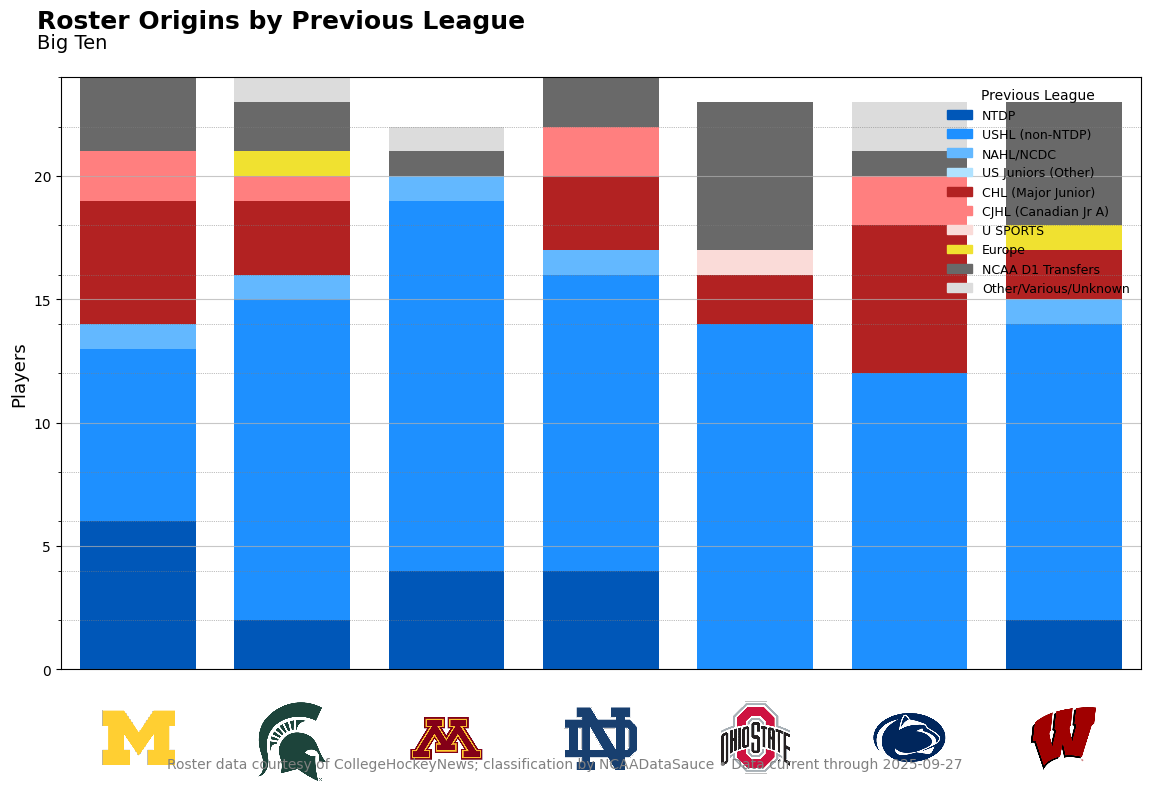

[WARN] Some teams lost rows in the pivot:
Current Team
Notre Dame       -76.0
Michigan         -76.0
Michigan State   -76.0
Wisconsin        -77.0
Ohio State       -77.0
Penn State       -77.0
Minnesota        -78.0
dtype: float64


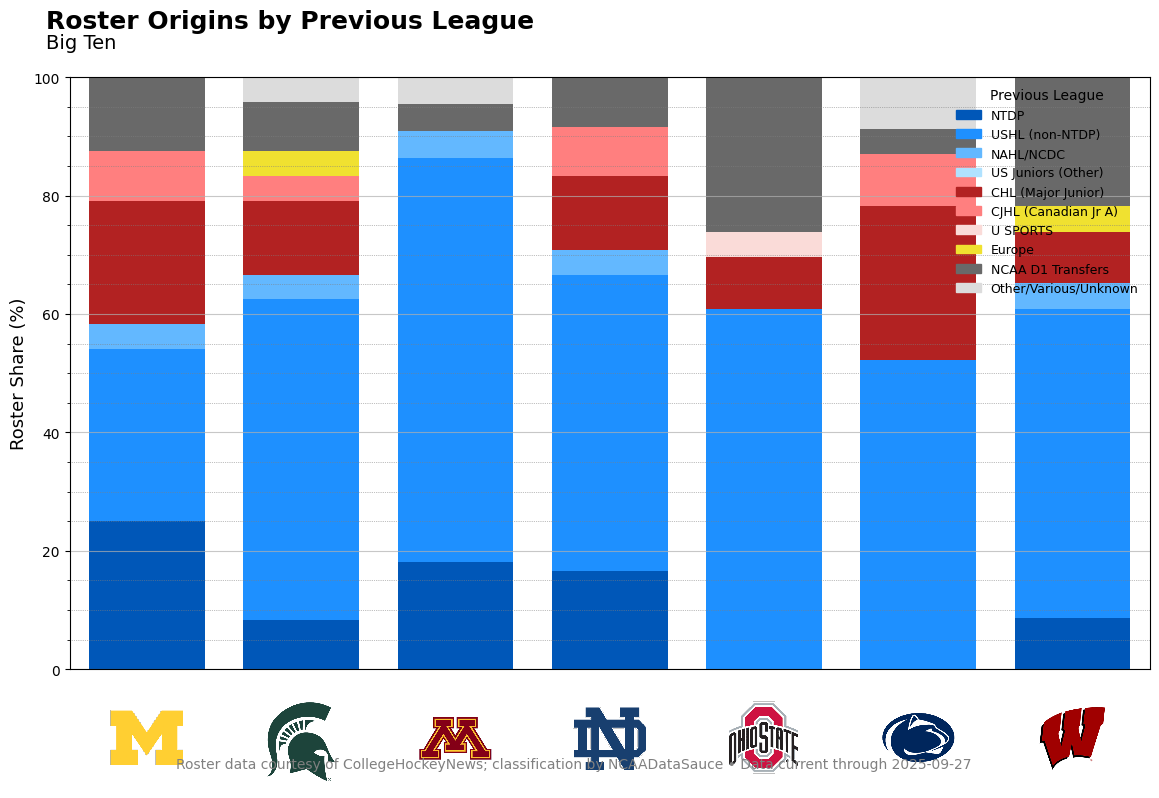

Prev_League_Bin,NTDP,USHL (non‑NTDP),NAHL/NCDC,US Juniors (Other),CHL (Major Junior),CJHL (Canadian Jr A),U SPORTS,Europe,NCAA D1 Transfers,Other/Various/Unknown
Current Team,,,,,,,,,,
Michigan,25.000000,29.166667,4.166667,0.0,20.833333,8.333333,0.000000,0.000000,12.500000,0.000000
Michigan State,8.333333,54.166667,4.166667,0.0,12.500000,4.166667,0.000000,4.166667,8.333333,4.166667
Minnesota,18.181818,68.181818,4.545455,0.0,0.000000,0.000000,0.000000,0.000000,4.545455,4.545455
Notre Dame,16.666667,50.000000,4.166667,0.0,12.500000,8.333333,0.000000,0.000000,8.333333,0.000000
Ohio State,0.000000,60.869565,0.000000,0.0,8.695652,0.000000,4.347826,0.000000,26.086957,0.000000
Penn State,0.000000,52.173913,0.000000,0.0,26.086957,8.695652,0.000000,0.000000,4.347826,8.695652
Wisconsin,8.695652,52.173913,4.347826,0.0,8.695652,0.000000,0.000000,4.347826,21.739130,0.000000


In [19]:
# Example usage (fill these in with your own data)
# big_ten = ["Michigan State","Michigan","Minnesota","Ohio State","Penn State","Wisconsin","Notre Dame"]
# logo_mapping = {"Michigan State":"msu.png", "Michigan":"um.png", ...}
# logo_folder = "/path/to/logos"

# Counts
plot_roster_origins_conference(
    df, big_ten, "Big Ten",
    logo_mapping=logo_mapping,
    logo_folder=logo_folder,
    normalize=False,
    save_path="/mnt/data/b1g_roster_origins_counts.png",
    date_note="Data current through 2025-09-27",
)

# Percentages
plot_roster_origins_conference(
    df, big_ten, "Big Ten",
    logo_mapping=logo_mapping,
    logo_folder=logo_folder,
    normalize=True,
    save_path="/mnt/data/b1g_roster_origins_pct.png",
    date_note="Data current through 2025-09-27",
)


### LEGACY - Data Cleaning and Modifications
- Remove Trouble character from Team Names

In [20]:

df = roster_2025_df.copy()
# # --- Helpers ---
# def _norm(s: str) -> str:
#     if pd.isna(s):
#         return ""
#     s = str(s).strip().upper()
#     # normalize hyphens/dashes and spaces
#     s = re.sub(r"[.\u2010-\u2015\-–—]+", " ", s)
#     s = re.sub(r"\s+", " ", s).strip()
#     return s

# # NTDP detection patterns (team or league)
# NTDP_TEAM_HINTS = (
#     "USA U 18", "US U 18", "USA U18", "US U18",
#     "USA U 17", "US U 17", "USA U17", "US U17",
#     "NTDP", "USNTDP", "US NATIONAL TEAM", "US DEV PROGRAM", "US DEVELOPMENT PROGRAM"
# )
# NTDP_LEAGUE_HINTS = ("NTDP",)

# # D1 conference tags imply NCAA D1 transfers
# D1_CONFS = {"ECAC","CCHA","NCHC","HEA","B10","AHA","INDEPENDENTS","D I IND","NCAA"}

# # Canadian Jr A leagues (CJHL family)
# CJHL_LEAGUES = {"BCHL","AJHL","SJHL","MJHL","OJHL","CCHL","MHL"}

# # US juniors (non-NTDP)
# US_TIER1 = {"USHL"}                    # NTDP plays USHL but we special-case by team name
# US_TIER2 = {"NAHL","NCDC"}
# US_OTHER  = {"USPHL","NA3HL","EHL"}    # include common Tier III/independent

# # CHL major junior
# CHL = {"OHL","WHL","QMJHL"}

# # Europe: anything clearly European junior/pro
# EURO_HINTS = {
#     "J20 NATIONELL","J18 REGION","U20 SM SARJA","U18","U20","SM SARJA",
#     "SHL","ICEHL","ALPSHL","LIIGA","MHL RUSSIA","KHL"
# }

# # Keywords to detect Russian MHL vs Maritime MHL (Canada)
# RUSSIAN_MHL_TEAM_HINTS = (
#     "KRASNAYA", "LOKO", "RMHL", "MOSKVA", "MOSCOW", "ST PETERSBURG", "SKA", "LOKOMOTIV",
#     "DMITROV", "CHELYABINSK", "OMSK", "NOVOSIBIRSK", "MAGNITOGORSK", "NIZHNY", "YAROSLAVL",
# )

# # Final bins
# BIN_ORDER = [
#     "NTDP",
#     "USHL (non‑NTDP)",
#     "NAHL/NCDC",
#     "US Juniors (Other)",
#     "CHL (Major Junior)",
#     "CJHL (Canadian Jr A)",
#     "U SPORTS",
#     "Europe",
#     "NCAA D1 Transfers",
#     "Other/Various/Unknown",
# ]

def classify_prev_bin(last_team: str, league: str) -> str:
    t = _norm(last_team)
    l = _norm(league)

    # --- NTDP carve-out (by team OR league) ---
    if any(h in t for h in NTDP_TEAM_HINTS) or any(h == l for h in NTDP_LEAGUE_HINTS):
        return "NTDP"

    # --- NCAA D1 transfers ---
    if (l in D1_CONFS) or ("NCAA" in l and l != ""):
        return "NCAA D1 Transfers"

    # --- U SPORTS ---
    if l in {"USPORTS", "U SPORTS"}:
        return "U SPORTS"

    # --- CHL major junior ---
    if l in CHL:
        return "CHL (Major Junior)"

    # --- Canadian Jr A vs Russian MHL ambiguity ---
    if l == "MHL":
        # Heuristic: if team name looks Russian -> Europe; otherwise treat as Maritime Jr A
        if any(k in t for k in RUSSIAN_MHL_TEAM_HINTS):
            return "Europe"
        else:
            return "CJHL (Canadian Jr A)"

    if l in CJHL_LEAGUES:
        return "CJHL (Canadian Jr A)"

    # --- US juniors (non-NTDP) ---
    if l in US_TIER1:
        # If the team wasn't caught by NTDP carve-out, it's a standard USHL team
        return "USHL (non‑NTDP)"
    if l in US_TIER2:
        return "NAHL/NCDC"
    if (l in US_OTHER) or ("USPHL" in l) or ("NA3HL" in l) or ("EHL" in l):
        return "US Juniors (Other)"

    # --- Europe consolidated ---
    if (l in EURO_HINTS) or any(h in l for h in EURO_HINTS):
        return "Europe"

    # --- Prep/HS/D3 go to Other per your new spec ---
    if l in {"D III","DIII","NCAA D3","PREP","USHS","CISAA","PHC"}:
        return "Other/Various/Unknown"

    # --- Fallbacks/Unknown ---
    if l == "" or pd.isna(league):
        return "Other/Various/Unknown"

    # If we still can't classify, try last_team-based hints
    if any(h in t for h in ("PREP","HS","HIGH SCHOOL","CISAA","PHC")):
        return "Other/Various/Unknown"
    if "U SPORTS" in t:
        return "U SPORTS"

    return "Other/Various/Unknown"

# Apply classification
df['prev_bin'] = df.apply(lambda row: classify_prev_bin(row['Last Team'], row['League']), axis=1)

In [21]:
def add_logos_to_plot(data_df, x_col, y_col, logo_mapping, logo_folder, ax, teams_in_region):
    for team in teams_in_region:
        team_data = data_df[data_df['Team'] == team]
        if not team_data.empty:
            x = team_data[x_col].values[0]
            y = team_data[y_col].values[0]
            logo_path = os.path.join(logo_folder, logo_mapping.get(team, ""))

            # Add this print statement to check the file paths
            print(f"Attempting to load logo for {team}: {logo_path}")
            
            if logo_path:
                try:
                    logo_img = plt.imread(logo_path)
                    imagebox = OffsetImage(logo_img, zoom=0.15)  # Adjust zoom as needed
                    ab = AnnotationBbox(imagebox, (x, y), frameon=False, xybox=(10, 20), boxcoords="offset points", pad=0)
                    ax.add_artist(ab)
                except Exception as e:
                    print(f"Error adding logo for {team}: {e}")  # Add this exception handling

# Fix the add_logos_to_plot function to avoid KeyError
def add_logos_to_plot(data_df, team_names, logo_mapping, logo_folder, ax, bar_width):
    for i, team in enumerate(team_names):
        logo_file = logo_mapping.get(team, "")
        if logo_file:
            logo_path = os.path.join(logo_folder, logo_file)
            try:
                logo_img = plt.imread(logo_path)
                imagebox = OffsetImage(logo_img, zoom=0.175)  # Adjust zoom as needed
                # Adjust the positioning of logos below the x-axis
                ab = AnnotationBbox(imagebox, (i + bar_width / 2, -0.055), xycoords=('data', 'axes fraction'), frameon=False)
                ax.add_artist(ab)
            except Exception as e:
                print(f"Error adding logo for {team}: {e}")



def add_conference_logo_fixed(fig,
                              logo_path,
                              height_frac=0.10,
                              max_width_frac=0.24,
                              x=0.03, y=0.995):
    """
    Draw logo in figure coords and return the x-position of its right edge
    (so we can place text after it).
    """
    img = Image.open(logo_path)
    img_w, img_h = img.size

    fig_w_px  = fig.get_figwidth()  * fig.dpi
    fig_h_px  = fig.get_figheight() * fig.dpi

    zoom = (height_frac * fig_h_px) / img_h
    # cap width for ultra-wide logos
    if (img_w * zoom) > (max_width_frac * fig_w_px):
        zoom = (max_width_frac * fig_w_px) / img_w

    # width in *figure-fraction* units
    logo_w_frac = (img_w * zoom) / fig_w_px
    logo_right  = x + logo_w_frac

    oi = OffsetImage(img, zoom=zoom)
    ab = AnnotationBbox(oi, (x, y), xycoords=fig.transFigure,
                        frameon=False, box_alignment=(0, 1))
    fig.add_artist(ab)

    return logo_right



In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator

# --- If you didn't keep these in scope, re-define them here ---
BIN_ORDER = [
    "NTDP",
    "USHL (non-NTDP)",
    "NAHL/NCDC",
    "US Juniors (Other)",
    "CHL (Major Junior)",
    "CJHL (Canadian Jr A)",
    "U SPORTS",
    "Europe",
    "NCAA D1 Transfers",
    "Other/Various/Unknown",
]

COLOR_MAP = {
    "NTDP": "#0057B8",
    "USHL (non-NTDP)": "#1E90FF",
    "NAHL/NCDC": "#63B8FF",
    "US Juniors (Other)": "#B0E2FF",
    "CHL (Major Junior)": "#B22222",
    "CJHL (Canadian Jr A)": "#FF7F7F",
    "U SPORTS": "#FADBD8",
    "Europe": "#2E8B57",
    "NCAA D1 Transfers": "#696969",
    "Other/Various/Unknown": "#DCDCDC",
}

def _order_teams(df, conference_teams, rank_df=None):
    """
    Return a list of teams ordered by rank_df['Rk'] if given,
    otherwise preserve the order in conference_teams.
    """
    teams = [t for t in conference_teams if t in set(df["Current Team"].unique())]
    if rank_df is None or "Team" not in rank_df.columns or "Rk" not in rank_df.columns:
        return teams
    rk_map = dict(zip(rank_df["Team"], rank_df["Rk"]))
    return sorted(teams, key=lambda t: rk_map.get(t, 10**9))

def plot_conference_origins(
    df,
    conference_teams,
    conference_name,
    logo_mapping,
    logo_folder,
    ax=None,
    rank_df=None,
    figure_size=(12, 8),
    normalize=False,        # False = counts, True = percentage of roster
    conference_logo=None,   # optional: 'big_ten.png', etc. (use your add_conference_logo_fixed)
    save_path=None,         # optional: path to save png
    header_title="Roster Origins by Previous League",
    source_note="Roster data courtesy of CollegeHockeyNews; classification by NCAADataSauce",
    date_note=None,         # e.g., "Data current through 2025-09-27"
):
    """
    Build a stacked bar per team using Prev_League_Bin, ordered by BIN_ORDER and colored by COLOR_MAP.
    """

    # ---------- filter & ordering ----------
    plot_teams = _order_teams(df, conference_teams, rank_df)
    if not plot_teams:
        raise ValueError("No teams from conference_teams present in df['Current Team'].")

    sub = df[df["Current Team"].isin(plot_teams)].copy()

    # pivot to Team x Bin table
    # use any non-null column to count rows (Last_Name is fine)
    table = (sub
        .pivot_table(index="Current Team",
                     columns="Prev_League_Bin",
                     values="Last_Name",
                     aggfunc="count",
                     fill_value=0)
        .reindex(index=plot_teams)
        .reindex(columns=BIN_ORDER, fill_value=0))

    # normalize to percentages if requested
    if normalize:
        denom = table.sum(axis=1).replace(0, np.nan)
        table = (table.T / denom).T.fillna(0.0) * 100.0

    # ---------- figure / axes ----------
    created_ax = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figure_size)
        created_ax = True
    else:
        fig = ax.figure

    # header/footer layout similar to your style
    HEADER_FRAC = 0.12
    BOTTOM_FRAC = 0.12
    fig.subplots_adjust(left=0.08, right=0.98, bottom=BOTTOM_FRAC, top=1-HEADER_FRAC)

    # ---------- stacked bars ----------
    x = np.arange(len(plot_teams))
    width = 0.75
    bottoms = np.zeros(len(plot_teams), dtype=float)

    bars_by_bin = {}
    for b in BIN_ORDER:
        heights = table[b].values
        color = COLOR_MAP.get(b, "#ccc")
        bars = ax.bar(x, heights, width=width, bottom=bottoms, color=color, edgecolor="none", label=b)
        bars_by_bin[b] = bars
        bottoms += heights

    # ---------- axes style ----------
    ax.set_xlim(-0.5, len(plot_teams)-0.5)
    ax.set_xticks([])   # hide text labels; we’ll draw logos instead
    ax.set_ylabel("Roster Share (%)" if normalize else "Players", fontsize=14)

    # grid (primary + minor)
    ax.yaxis.grid(True, linestyle='-', alpha=0.7)
    if normalize:
        ax.set_ylim(0, 100)
        ax.yaxis.set_minor_locator(MultipleLocator(5))
    else:
        # pick a nice minor step based on max roster size
        ymax = max(5, int(np.ceil(bottoms.max())))
        ax.set_ylim(0, ymax)
        minor_step = 2 if ymax <= 30 else 5
        ax.yaxis.set_minor_locator(MultipleLocator(minor_step))
    ax.yaxis.grid(which='minor', linestyle=':', linewidth=0.5, color='gray')

    # carve space for logos below; use axes-fraction y < 0 for placement
    ax.set_ylim(ax.get_ylim()[0] * (1 - 0.05), ax.get_ylim()[1])  # tiny extra space at bottom

    # ---------- logos under bars ----------
    # expects your add_logos_to_plot(data_df, team_names, logo_mapping, logo_folder, ax, bar_width)
    # We pass the bar width so your helper positions them correctly.
    # Build a tiny frame with Team column to match your helper signature.
    logo_df = pd.DataFrame({"Team": plot_teams})
    add_logos_to_plot(logo_df, plot_teams, logo_mapping, logo_folder, ax, width)

    # ---------- legend ----------
    # in order, group by geography via simple headers in the legend block
    # We’ll build a compact legend row-by-row
    legend_handles = [mpatches.Patch(color=COLOR_MAP[b], label=b) for b in BIN_ORDER]
    leg = ax.legend(handles=legend_handles, loc="upper right", frameon=False, ncol=1, fontsize=10, title="Previous League")
    if leg and leg.get_title():
        leg.get_title().set_fontsize(11)

    # ---------- header & optional conference logo ----------
    title_x_left = 0.06
    if conference_logo:
        # requires your add_conference_logo_fixed(fig, logo_path, ...)
        logo_path = os.path.join(logo_folder, "conference", conference_logo)
        try:
            logo_right = add_conference_logo_fixed(fig, logo_path, height_frac=0.10, max_width_frac=0.24, x=0.03, y=0.995)
            title_x_left = max(title_x_left, logo_right + 0.02)
        except Exception as e:
            print(f"[warn] conference logo failed: {e}")

    fig.text(title_x_left, 0.965, header_title, ha="left", va="top", fontsize=18, weight="bold")
    fig.text(title_x_left, 0.935, f"{conference_name}", ha="left", va="top", fontsize=14)

    # ---------- footer note ----------
    footer_note = source_note
    if date_note:
        footer_note += f" • {date_note}"
    fig.text(0.5, 0.01, footer_note, ha="center", va="bottom", fontsize=10, color="gray")

    # ---------- save/show ----------
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    if created_ax:
        plt.show()

    return table  # return the Team x Bin table used for plotting (nice for QC)


In [23]:
# Example inputs you likely already have:
# df  -> your roster with 'Current Team' and 'Prev_League_Bin'
# big_ten -> list of teams in the conference
# logo_mapping -> dict: {team: "team_logo.png"}
# logo_folder  -> path with those logo files

df = roster_2025_df

# 1) Absolute counts
_ = plot_conference_origins(
    df,
    conference_teams=big_ten,
    conference_name="Big Ten",
    logo_mapping=logo_mapping,
    logo_folder=logo_folder,
    rank_df=pairwise_df,            # optional; must have Team/Rk
    conference_logo="big_ten_orig.png",
    figure_size=(12,8),
    normalize=False,
    save_path=os.path.join(temp_folder, "big_ten_roster_origins_counts.png"),
    header_title="Roster Origins by Previous League",
    date_note="Data current through 2025-09-27",
)

# 2) Percent of roster
_ = plot_conference_origins(
    df,
    conference_teams=hockey_east,
    conference_name="Hockey East",
    logo_mapping=logo_mapping,
    logo_folder=logo_folder,
    rank_df=pairwise_df,            # optional
    conference_logo="hockey_east.png",
    figure_size=(12,8),
    normalize=True,                 # percentage
    save_path=os.path.join(temp_folder, "hockey_east_roster_origins_pct.png"),
    header_title="Roster Origins (% of Roster)",
    date_note="Data current through 2025-09-27",
)


KeyError: 'Prev_League_Bin'

In [ ]:
# COlumns to List
print(roster_2025_df.columns.tolist())

## last team value counts
print(roster_2025_df['last team'].value_counts())

In [ ]:
# Show all players with USA U-18 Team
usa_u18_players = df[df['last team'] == 'USA U-18 Team']
print(usa_u18_players)

usa_u18_players.head()

In [ ]:
# ## Value Count of League
# print(roster_2025_df['league'].value_counts())

# # print leagues as a list
# print(roster_2025_df['league'].unique().tolist())

In [ ]:
# import pandas as pd
# import numpy as np
# import re

# # --- canonical bins (order here is what you’ll see in columns later)
# BIN_ORDER = [
#     "NCAA D1 (Transfer)",
#     "NCAA D3 (Transfer)",
#     "U SPORTS (Canada)",
#     "Major Junior (CHL)",
#     "Canadian Jr A (CJHL)",
#     "US Junior Tier I (USHL/NTDP)",
#     "US Junior Tier II (NAHL/NCDC)",
#     "US Junior Other (USPHL)",
#     "Prep/High School",
#     "Europe Junior (U20/U18)",
#     "Professional/Senior",
#     "Unknown/Other",
# ]

# def _norm(s):
#     if pd.isna(s):
#         return np.nan
#     # normalize: uppercase, collapse punctuation/spaces
#     s = str(s).strip().upper()
#     s = re.sub(r"[.\u2010-\u2015\-–—]+", " ", s)  # hyphen/emdash variants -> space
#     s = re.sub(r"\s+", " ", s).strip()
#     return s

# # direct lookup on normalized keys
# LEAGUE_TO_BIN = {
#     # Major junior (CHL)
#     "OHL": "Major Junior (CHL)",
#     "WHL": "Major Junior (CHL)",
#     "QMJHL": "Major Junior (CHL)",

#     # Canadian Jr A (CJHL)
#     "BCHL": "Canadian Jr A (CJHL)",
#     "AJHL": "Canadian Jr A (CJHL)",
#     "SJHL": "Canadian Jr A (CJHL)",
#     "MJHL": "Canadian Jr A (CJHL)",
#     "OJHL": "Canadian Jr A (CJHL)",
#     "CCHL": "Canadian Jr A (CJHL)",
#     "MHL": "Canadian Jr A (CJHL)",          # NOTE: if Russian MHL appears, we can fork it
#     "AJHL BCHL": "Canadian Jr A (CJHL)",     # normalized "AJHL/BCHL"

#     # US juniors
#     "USHL": "US Junior Tier I (USHL/NTDP)",
#     "NTDP": "US Junior Tier I (USHL/NTDP)",
#     "NAHL": "US Junior Tier II (NAHL/NCDC)",
#     "NCDC": "US Junior Tier II (NAHL/NCDC)",
#     "USPHL": "US Junior Other (USPHL)",      # treat non-NCDC USPHL as "other"

#     # NCAA D1 conferences / labels
#     "ECAC": "NCAA D1 (Transfer)",
#     "CCHA": "NCAA D1 (Transfer)",
#     "NCHC": "NCAA D1 (Transfer)",
#     "HEA":  "NCAA D1 (Transfer)",
#     "B10":  "NCAA D1 (Transfer)",
#     "AHA":  "NCAA D1 (Transfer)",
#     "INDEPENDENTS": "NCAA D1 (Transfer)",
#     "D I IND": "NCAA D1 (Transfer)",
#     "NCAA": "NCAA D1 (Transfer)",

#     # NCAA D3 variants
#     "D III": "NCAA D3 (Transfer)",
#     "DIII":  "NCAA D3 (Transfer)",
#     "NCAA D3": "NCAA D3 (Transfer)",

#     # Canadian university
#     "USPORTS": "U SPORTS (Canada)",
#     "U SPORTS": "U SPORTS (Canada)",

#     # Prep/HS
#     "PREP": "Prep/High School",
#     "USHS": "Prep/High School",
#     "PHC":  "Prep/High School",   # Prep Hockey Conference (assumption)
#     "CISAA":"Prep/High School",

#     # Europe junior
#     "J20 NATIONELL": "Europe Junior (U20/U18)",
#     "J18 REGION":    "Europe Junior (U20/U18)",
#     "U20 SM SARJA":  "Europe Junior (U20/U18)",
#     "SM SARJA":      "Europe Junior (U20/U18)",  # ambiguous; bump to Pro later if needed

#     # Professional / senior
#     "AHL":    "Professional/Senior",
#     "ECHL":   "Professional/Senior",
#     "SHL":    "Professional/Senior",
#     "ALPSHL": "Professional/Senior",
#     "ICEHL":  "Professional/Senior",

#     # Unknown / showcase
#     "JPL PRO": "Unknown/Other",
# }

# # fallback heuristics to catch near-misses
# D1_HINTS = {"ECAC","CCHA","NCHC","HEA","B10","AHA","INDEPENDENTS","D I IND","NCAA"}
# EU_JR_HINTS = ("J20","J18","U20","U18","SM SARJA")
# PRO_HINTS = ("AHL","ECHL","SHL","ICEHL","ALPS")
# PREP_HINTS = ("PREP","USHS","CISAA","PHC")
# CJHL_HINTS = ("BCHL","AJHL","SJHL","MJHL","OJHL","CCHL","MHL")

# def classify_prev_league(value):
#     if pd.isna(value):
#         return "Unknown/Other"
#     s = _norm(value)

#     # exact map first
#     if s in LEAGUE_TO_BIN:
#         return LEAGUE_TO_BIN[s]

#     # heuristics for slightly off labels
#     if any(h == s for h in D1_HINTS) or "NCAA" in s:
#         return "NCAA D1 (Transfer)"
#     if any(h in s for h in CJHL_HINTS):
#         return "Canadian Jr A (CJHL)"
#     if s in {"USHL","NTDP"}:
#         return "US Junior Tier I (USHL/NTDP)"
#     if "NAHL" in s or "NCDC" in s:
#         return "US Junior Tier II (NAHL/NCDC)"
#     if "USPHL" in s:
#         return "US Junior Other (USPHL)"
#     if any(h in s for h in PREP_HINTS):
#         return "Prep/High School"
#     if any(h in s for h in EU_JR_HINTS):
#         return "Europe Junior (U20/U18)"
#     if any(h in s for h in PRO_HINTS):
#         return "Professional/Senior"

#     return "Unknown/Other"

# # --- USAGE EXAMPLE ---
# df = roster_2025_df
# # df is your roster table with a 'league' column and 'Current Team'
# df['Prev_League_Bin'] = df['league'].apply(classify_prev_league)

# # Team x Bin counts (for stacking)
# # league_counts = (df.assign(Prev_League_Bin=df['league'].apply(classify_prev_league))
# #                    .pivot_table(index='Current Team',
# #                                  columns='Prev_League_Bin',
# #                                  values='Last_Name',  # any non-null column
# #                                  aggfunc='count',
# #                                  fill_value=0)
# #                    .reindex(columns=BIN_ORDER, fill_value=0))
